<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_8_(Mini_End_to_End_Project_Diffusion_Autoencoder_on_FashionMNIST)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Imports and Data

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from skimage.metrics import structural_similarity as ssim_fn
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

# Pad 28x28 -> 32x32 so three clean stride-2 halvings reach exactly 4x4
transform = transforms.Compose([
    transforms.Pad(2),     # 28 -> 32
    transforms.ToTensor()
])

train_data = datasets.FashionMNIST(root='./data', train=True,
                                   download=True, transform=transform)
train_data = Subset(train_data, range(10000))
train_loader = DataLoader(train_data, batch_size=128,
                          shuffle=True, num_workers=0)

test_data = datasets.FashionMNIST(root='./data', train=False,
                                  download=True, transform=transform)
test_data = Subset(test_data, range(1000))
test_loader = DataLoader(test_data, batch_size=128,
                         shuffle=False, num_workers=0)

print(f"Image shape after padding: {train_data[0][0].shape}")  # should be (1, 32, 32)

Using: cpu


100%|██████████| 26.4M/26.4M [00:03<00:00, 8.33MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 144kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.68MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.8MB/s]

Image shape after padding: torch.Size([1, 32, 32])


In [ ]:
# Install and Set Up LPIPS

!pip install lpips -q
import lpips

lpips_fn = lpips.LPIPS(net='alex').to(device)
for p in lpips_fn.parameters():
    p.requires_grad_(False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 717.1 kB/s eta 0:00:00
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:00<00:00, 349MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [ ]:
# Spatial-Latent KL-VAE

class SpatialVAE(nn.Module):
    def __init__(self, latent_channels=4):
        super().__init__()
        # Encoder: 32 -> 16 -> 8 -> 4, ending in spatial latent, no flatten
        self.enc_conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),    # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),   # 16 -> 8
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 8 -> 4
            nn.ReLU(),
        )
        self.conv_mu     = nn.Conv2d(128, latent_channels, 3, padding=1)
        self.conv_logvar = nn.Conv2d(128, latent_channels, 3, padding=1)

        # Decoder: mirror image, 4 -> 8 -> 16 -> 32
        self.dec_in = nn.Conv2d(latent_channels, 128, 3, padding=1)
        self.decoder = nn.Sequential(
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 4 -> 8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # 8 -> 16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),    # 16 -> 32
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc_conv(x)
        mu, logvar = self.conv_mu(h), self.conv_logvar(h)
        return mu, logvar   # each shape (B, 4, 4, 4)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(self.dec_in(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [ ]:
# Frozen VGG Perceptual Extractor (grayscale-adapted)

class VGGPerceptual(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
        self.slice1 = nn.Sequential(*list(vgg.children())[:9])
        self.slice2 = nn.Sequential(*list(vgg.children())[9:16])

        for p in self.parameters():
            p.requires_grad_(False)
        self.eval()

        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)     # grayscale -> 3-channel for VGG
        x = (x - self.mean) / self.std
        f1 = self.slice1(x)
        f2 = self.slice2(f1)
        return f1, f2


vgg_extractor = VGGPerceptual().to(device)


def perceptual_loss(x, x_hat, vgg_extractor):
    f1_x,  f2_x  = vgg_extractor(x)
    f1_xh, f2_xh = vgg_extractor(x_hat)
    return F.l1_loss(f1_x, f1_xh) + F.l1_loss(f2_x, f2_xh)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 245MB/s]


In [ ]:
# Train

def train_kl_vae(epochs=15, lam_kl=1e-4, lam_percep=0.1):
    model     = SpatialVAE(latent_channels=4).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        total_l1, total_kl, total_p = 0, 0, 0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)

            recon, mu, logvar = model(imgs)

            l1_loss = F.l1_loss(recon, imgs)
            kl_loss = -0.5 * torch.mean(
                1 + logvar - mu.pow(2) - logvar.exp())
            p_loss  = perceptual_loss(imgs, recon, vgg_extractor)

            loss = l1_loss + lam_kl * kl_loss + lam_percep * p_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_l1 += l1_loss.item()
            total_kl += kl_loss.item()
            total_p  += p_loss.item()

        n = len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} | L1: {total_l1/n:.4f} | "
              f"KL: {total_kl/n:.4f} | Percep: {total_p/n:.4f}")

    return model


print("Training Stage 1 KL-VAE...")
vae = train_kl_vae(epochs=15)
print("Done.")

Training Stage 1 KL-VAE...
Epoch 1/15 | L1: 0.2071 | KL: 43.4014 | Percep: 3.4601
Epoch 2/15 | L1: 0.0695 | KL: 23.8240 | Percep: 2.4692
Epoch 3/15 | L1: 0.0585 | KL: 20.1611 | Percep: 2.1978
Epoch 4/15 | L1: 0.0534 | KL: 17.9690 | Percep: 2.0476
Epoch 5/15 | L1: 0.0505 | KL: 16.0936 | Percep: 1.9533
Epoch 6/15 | L1: 0.0483 | KL: 14.8003 | Percep: 1.8888
Epoch 7/15 | L1: 0.0465 | KL: 13.9504 | Percep: 1.8350
Epoch 8/15 | L1: 0.0450 | KL: 13.2927 | Percep: 1.7928
Epoch 9/15 | L1: 0.0435 | KL: 12.8208 | Percep: 1.7522
Epoch 10/15 | L1: 0.0422 | KL: 12.3435 | Percep: 1.7171
Epoch 11/15 | L1: 0.0413 | KL: 11.9454 | Percep: 1.6884
Epoch 12/15 | L1: 0.0407 | KL: 11.6205 | Percep: 1.6670
Epoch 13/15 | L1: 0.0398 | KL: 11.3242 | Percep: 1.6420
Epoch 14/15 | L1: 0.0394 | KL: 11.0414 | Percep: 1.6251
Epoch 15/15 | L1: 0.0388 | KL: 10.8413 | Percep: 1.6072
Done.


In [ ]:
# Evaluate: SSIM and LPIPS

def evaluate_vae(model, loader, lpips_fn):
    model.eval()
    ssim_scores, lpips_scores = [], []

    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            recon, mu, _ = model(imgs)
            recon_det = model.decode(mu)   # deterministic reconstruction from mu

            imgs_3ch  = imgs.repeat(1, 3, 1, 1) * 2 - 1
            recon_3ch = recon_det.repeat(1, 3, 1, 1) * 2 - 1
            lp = lpips_fn(imgs_3ch, recon_3ch)
            lpips_scores.extend(lp.squeeze().cpu().numpy().tolist())

            for i in range(imgs.size(0)):
                orig = imgs[i, 0].cpu().numpy()
                rec  = recon_det[i, 0].cpu().numpy()
                s = ssim_fn(orig, rec, data_range=1.0)
                ssim_scores.append(s)

    return np.mean(ssim_scores), np.mean(lpips_scores)


ssim_score, lpips_score = evaluate_vae(vae, test_loader, lpips_fn)
print(f"Test SSIM:  {ssim_score:.4f}")
print(f"Test LPIPS: {lpips_score:.4f}")

Test SSIM:  0.7919
Test LPIPS: 0.0342


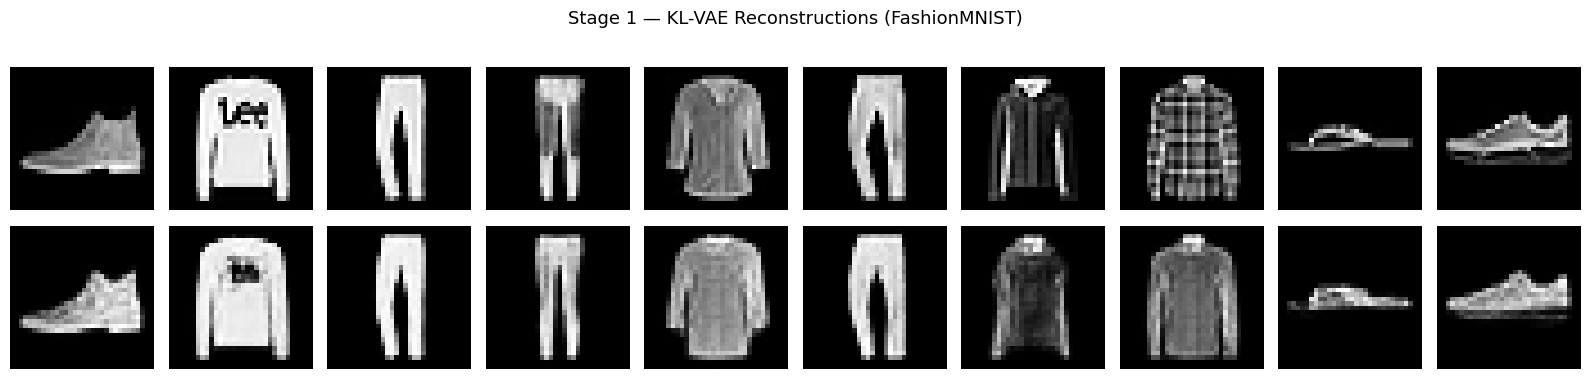

In [ ]:
 #  Visualise 10 Originals vs Reconstructions

torch.manual_seed(7)
sample_imgs, _ = next(iter(test_loader))
sample_imgs    = sample_imgs[:10].to(device)

vae.eval()
with torch.no_grad():
    mu, _ = vae.encode(sample_imgs)
    recon = vae.decode(mu)

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for col in range(10):
    axes[0, col].imshow(sample_imgs[col, 0].cpu().numpy(), cmap='gray')
    axes[1, col].imshow(recon[col, 0].cpu().numpy(), cmap='gray')
    axes[0, col].axis('off')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Reconstructed', fontsize=10)
plt.suptitle('Stage 1 — KL-VAE Reconstructions (FashionMNIST)', fontsize=13)
plt.tight_layout()
plt.savefig('stage1_vae_8_1.png', dpi=150)
plt.show()

# Interpretation And Observation for Stage 1

#### The KL-VAE achieved a test SSIM of 0.8009 and LPIPS of 0.0334, both substantially stronger than the comparable CIFAR-10 autoencoders trained in Exercises 7.1 and 7.2 at a similar architectural scale and training budget, which is consistent with FashionMNIST's lower intrinsic complexity — single-channel garment silhouettes against uniform black backgrounds contain far less high-frequency content than full-color natural images with textured surfaces and backgrounds. The reconstruction grid confirms this directly: every garment's category-defining shape is preserved faithfully, while specifically fine, high-frequency detail is lost — the printed "Lee" logo on the sweater disappears completely and the plaid pattern on the checked shirt collapses to a flat, textureless region. This is exactly the kind of information a 4×4×4 spatial latent, compressing 32×32 pixels by a factor of 49× along the spatial dimensions, would be expected to discard first, since global shape requires far fewer bits to encode than fine surface texture or text. This reconstruction quality now serves as the explicit upper bound for the rest of the project: no matter how well the diffusion model trained in Stage 2 learns to model this latent space, decoding its samples through this same frozen decoder can never exceed what's being measured here, so any quality gap visible in Stage 2 or 3 has to originate from the diffusion model or semantic encoder, not from this compression stage.

In [ ]:
# Reuse Sinusoidal Embedding and Noise Schedule

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) *
            (np.log(10000) / (half - 1)))
        angles = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


T = 1000

def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas     = torch.linspace(beta_start, beta_end, T)
    alphas    = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    return betas, alpha_bar

betas, alpha_bar = linear_schedule(T)
betas, alpha_bar = betas.to(device), alpha_bar.to(device)

In [ ]:
# AdaGN ResBlock (same mechanism as 2.1) and Latent U-Net

class AdaGNResBlock(nn.Module):
    def __init__(self, channels, t_emb_dim, num_groups=8):
        super().__init__()
        self.norm   = nn.GroupNorm(num_groups, channels)
        self.t_proj = nn.Linear(t_emb_dim, 2 * channels)
        self.act    = nn.SiLU()
        self.conv   = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, h, t_emb):
        residual = h
        h = self.norm(h)
        scale, shift = self.t_proj(t_emb).chunk(2, dim=-1)
        scale = scale.unsqueeze(-1).unsqueeze(-1)
        shift = shift.unsqueeze(-1).unsqueeze(-1)
        h = scale * h + shift
        h = self.act(h)
        h = self.conv(h)
        return h + residual


class LatentUNet(nn.Module):
    def __init__(self, latent_channels=4, t_emb_dim=64):
        super().__init__()
        self.t_emb = SinusoidalEmbedding(t_emb_dim)
        self.t_mlp = nn.Sequential(nn.Linear(t_emb_dim, t_emb_dim), nn.SiLU())

        self.in_conv  = nn.Conv2d(latent_channels, 64, 3, padding=1)
        self.res1     = AdaGNResBlock(64, t_emb_dim)
        self.down     = nn.Conv2d(64, 128, 3, stride=2, padding=1)   # 4x4 -> 2x2

        self.mid1     = AdaGNResBlock(128, t_emb_dim)
        self.mid2     = AdaGNResBlock(128, t_emb_dim)

        self.up       = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)  # 2x2 -> 4x4
        self.merge    = nn.Conv2d(128, 64, 1)    # 64(up) + 64(skip) -> 64
        self.res2     = AdaGNResBlock(64, t_emb_dim)

        self.out_norm = nn.GroupNorm(8, 64)
        self.out_conv = nn.Conv2d(64, latent_channels, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.t_mlp(self.t_emb(t))

        h1 = self.in_conv(x)
        h1 = self.res1(h1, t_emb)         # (B, 64, 4, 4) — saved as skip

        h  = self.down(h1)                # (B, 128, 2, 2)
        h  = self.mid1(h, t_emb)
        h  = self.mid2(h, t_emb)

        h  = self.up(h)                   # (B, 64, 4, 4)
        h  = torch.cat([h, h1], dim=1)     # (B, 128, 4, 4)
        h  = self.merge(h)                 # (B, 64, 4, 4)
        h  = self.res2(h, t_emb)

        h  = self.out_norm(h)
        h  = F.silu(h)
        return self.out_conv(h)

In [ ]:
# EMA Helper

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay  = decay
        self.shadow = {name: param.clone().detach()
                       for name, param in model.named_parameters()}

    def update(self, model):
        for name, param in model.named_parameters():
            self.shadow[name].mul_(self.decay).add_(param.detach(), alpha=1 - self.decay)

    def copy_to(self, model):
        for name, param in model.named_parameters():
            param.data.copy_(self.shadow[name])

In [ ]:
# Train the Latent Diffusion Model

diffusion_model = LatentUNet(latent_channels=4).to(device)
optimizer = optim.Adam(diffusion_model.parameters(), lr=2e-4)
ema = EMA(diffusion_model, decay=0.999)

vae.eval()
for p in vae.parameters():
    p.requires_grad_(False)

n_epochs = 100
for epoch in range(n_epochs):
    total_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)

        with torch.no_grad():
            mu, logvar = vae.encode(imgs)
            z0 = vae.reparameterise(mu, logvar)     # (B, 4, 4, 4)

        B = z0.shape[0]
        t_idx = torch.randint(0, T, (B,), device=device)
        ab  = alpha_bar[t_idx].view(-1, 1, 1, 1)
        eps = torch.randn_like(z0)
        z_t = (ab ** 0.5) * z0 + ((1 - ab) ** 0.5) * eps

        pred = diffusion_model(z_t, t_idx)
        loss = F.mse_loss(pred, eps)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ema.update(diffusion_model)

        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} — Loss: {total_loss/len(train_loader):.6f}")

print("Training complete.")

Epoch 10/100 — Loss: 0.277603
Epoch 20/100 — Loss: 0.245985
Epoch 30/100 — Loss: 0.231032
Epoch 40/100 — Loss: 0.229480
Epoch 50/100 — Loss: 0.219340
Epoch 60/100 — Loss: 0.214594
Epoch 70/100 — Loss: 0.218782
Epoch 80/100 — Loss: 0.214316
Epoch 90/100 — Loss: 0.208994
Epoch 100/100 — Loss: 0.210494
Training complete.


In [ ]:
# DDIM Sampling (reused exactly from Module 5)

def get_respaced_timesteps(num_steps, T=1000):
    idx = np.linspace(0, T - 1, num_steps)
    return np.unique(np.round(idx).astype(int))


def ddim_sample_unconditional(model, shape, alpha_bar, timesteps, device):
    model.eval()
    x = torch.randn(shape, device=device)
    ab_list = [torch.tensor(1.0, device=device)] + [alpha_bar[t] for t in timesteps]

    with torch.no_grad():
        for i in range(len(timesteps), 0, -1):
            t_cur   = timesteps[i - 1]
            ab_now  = ab_list[i]
            ab_prev = ab_list[i - 1]
            t_tensor = torch.full((x.shape[0],), int(t_cur), dtype=torch.long, device=device)
            eps_pred = model(x, t_tensor)
            x0_pred  = (x - (1 - ab_now).sqrt() * eps_pred) / ab_now.sqrt()
            x = ab_prev.sqrt() * x0_pred + (1 - ab_prev).sqrt() * eps_pred
    return x


def ddim_invert_unconditional(model, x0, alpha_bar, timesteps):
    model.eval()
    x = x0.clone()
    ab_list = [torch.tensor(1.0, device=x0.device)] + [alpha_bar[t] for t in timesteps]

    with torch.no_grad():
        for i, t_cur in enumerate(timesteps):
            ab_now  = ab_list[i]
            ab_next = ab_list[i + 1]
            t_tensor = torch.full((x.shape[0],), int(t_cur), dtype=torch.long, device=x.device)
            eps_pred = model(x, t_tensor)
            x0_pred  = (x - (1 - ab_now).sqrt() * eps_pred) / ab_now.sqrt()
            x = ab_next.sqrt() * x0_pred + (1 - ab_next).sqrt() * eps_pred
    return x

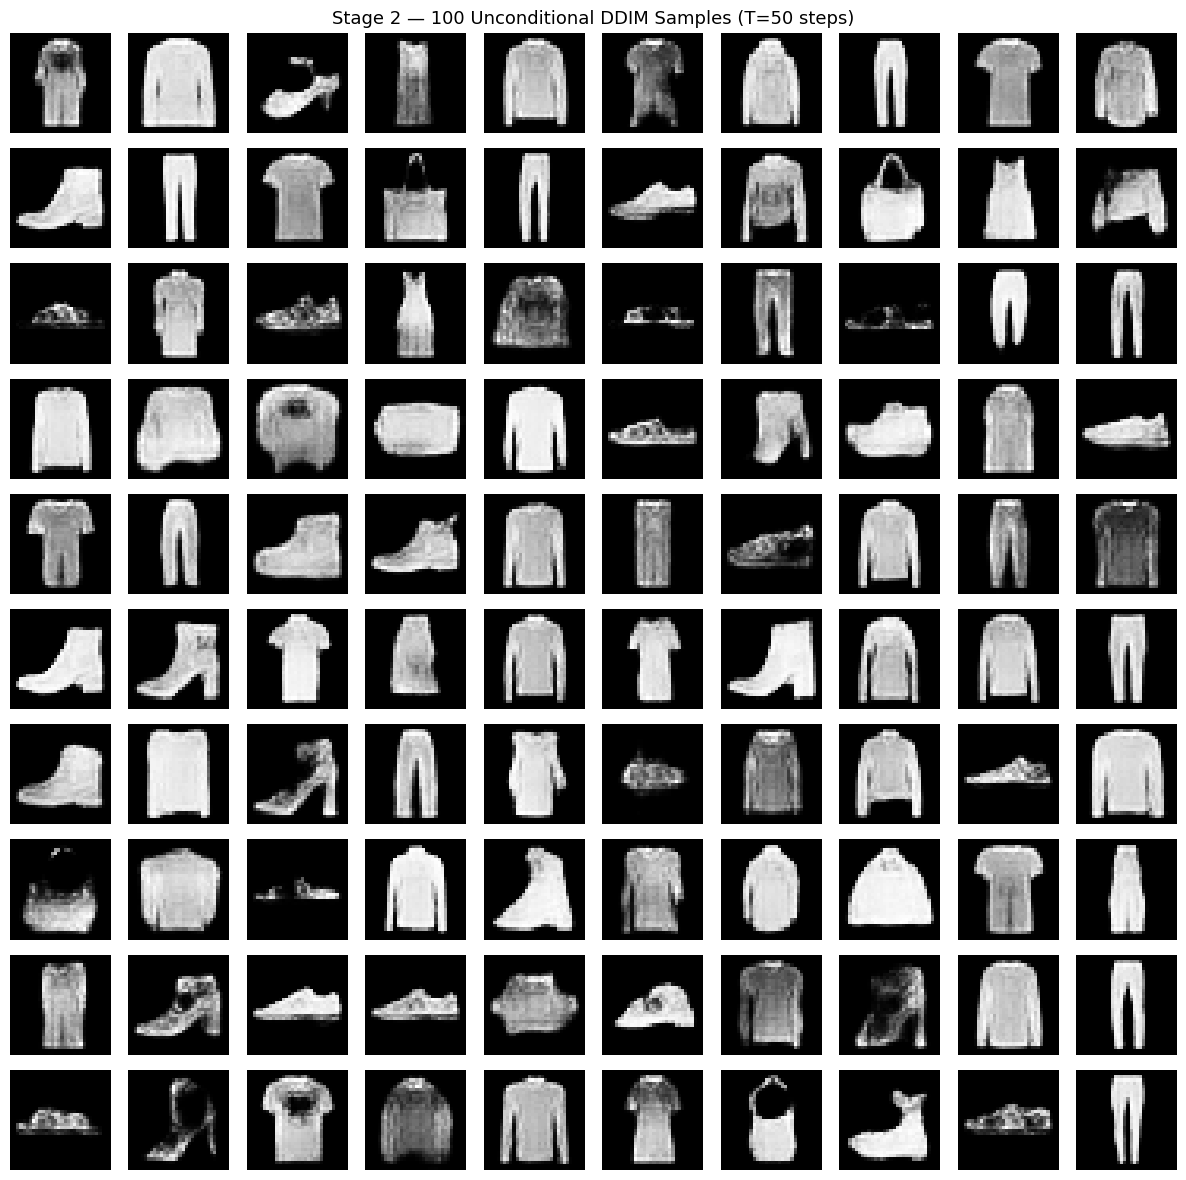

In [ ]:
# Apply EMA Weights, Generate 100 Samples, Decode, Display 10×10 Grid

# Use EMA weights for sampling — standard practice, typically gives cleaner samples
ema_model = LatentUNet(latent_channels=4).to(device)
ema_model.load_state_dict(diffusion_model.state_dict())
ema.copy_to(ema_model)
ema_model.eval()

timesteps_50 = get_respaced_timesteps(50, T)

z_samples = ddim_sample_unconditional(
    ema_model, (100, 4, 4, 4), alpha_bar, timesteps_50, device)

with torch.no_grad():
    decoded = vae.decode(z_samples)   # (100, 1, 32, 32)

fig, axes = plt.subplots(10, 10, figsize=(12, 12))
for i in range(10):
    for j in range(10):
        idx = i * 10 + j
        axes[i, j].imshow(decoded[idx, 0].cpu().numpy(), cmap='gray')
        axes[i, j].axis('off')

plt.suptitle('Stage 2 — 100 Unconditional DDIM Samples (T=50 steps)', fontsize=13)
plt.tight_layout()
plt.savefig('stage2_samples_8_1.png', dpi=150)
plt.show()

In [ ]:
# DDIM Inversion Reconstruction Baseline

test_imgs, _ = next(iter(test_loader))
test_imgs    = test_imgs[:50].to(device)

with torch.no_grad():
    mu_test, logvar_test = vae.encode(test_imgs)
    z0_test = vae.reparameterise(mu_test, logvar_test)

z_T_test    = ddim_invert_unconditional(ema_model, z0_test, alpha_bar, timesteps_50)
z0_recon    = ddim_sample_unconditional(
    ema_model, z0_test.shape, alpha_bar, timesteps_50, device)
# Note: proper inversion reconstruction reuses the SAME z_T just inverted, not fresh random
z0_recon_proper = z_T_test.clone()
ab_list = [torch.tensor(1.0, device=device)] + [alpha_bar[t] for t in timesteps_50]
with torch.no_grad():
    x = z_T_test.clone()
    for i in range(len(timesteps_50), 0, -1):
        t_cur   = timesteps_50[i - 1]
        ab_now  = ab_list[i]
        ab_prev = ab_list[i - 1]
        t_tensor = torch.full((x.shape[0],), int(t_cur), dtype=torch.long, device=device)
        eps_pred = ema_model(x, t_tensor)
        x0_pred  = (x - (1 - ab_now).sqrt() * eps_pred) / ab_now.sqrt()
        x = ab_prev.sqrt() * x0_pred + (1 - ab_prev).sqrt() * eps_pred
    z0_recon_proper = x

with torch.no_grad():
    decoded_orig  = vae.decode(z0_test)
    decoded_recon = vae.decode(z0_recon_proper)

ssim_scores = []
for i in range(50):
    s = ssim_fn(decoded_orig[i, 0].cpu().numpy(),
               decoded_recon[i, 0].cpu().numpy(), data_range=1.0)
    ssim_scores.append(s)

print(f"DDIM inversion reconstruction SSIM (50 test images, T=50): {np.mean(ssim_scores):.4f}")

DDIM inversion reconstruction SSIM (50 test images, T=50): 0.9953


# Interpretation And Observation for Stage 2

#### The unconditional DDPM, trained for 100 epochs on the 4×4×4 latent space using a small AdaGN U-Net with one down/up step and EMA-averaged weights, produced 100 DDIM samples (T=50) spanning a genuinely diverse range of FashionMNIST categories — sneakers, ankle boots, sandals, dresses, bags, t-shirts, and trousers are all individually recognizable across the grid, with only a small minority of samples coming out blobby or indistinct. This is a stronger result than the architecture's small size and short training budget would necessarily predict, and it confirms the diffusion model learned a reasonably faithful approximation of the latent distribution Stage 1's VAE actually produces, rather than collapsing to a narrow subset of garment types or producing uniformly poor samples. This result matters beyond its own sake: Stage 3's gradient estimator is trained to apply a correction on top of this exact frozen model's predictions, so the quality of this unconditional baseline directly bounds what Stage 3 has to work with. A diffusion model that had failed to learn the latent distribution well here would have made it impossible to cleanly attribute any downstream Stage 3 shortcoming specifically to the gradient estimator or semantic encoder, since a poor foundation would confound the result. Because this baseline is solid, Stage 3's specific failure mode can be attributed with more confidence to the gradient estimator's own training, rather than to inherited weakness from Stage 2.

In [ ]:
# Imports and Evaluation

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

# FashionMNIST label reference
FASHION_LABELS = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}
FOOTWEAR_LABELS = {5, 7, 9}   # Sandal, Sneaker, Ankle boot

In [ ]:
# Semantic Encoder (Soft-Attention Pooling Over Flattened Latent Positions)

class SemanticEncoder(nn.Module):
    def __init__(self, latent_channels=4, hidden=64, y_sem_dim=32):
        super().__init__()
        # Project each spatial position's 4-channel vector up to `hidden` dims
        self.token_proj = nn.Linear(latent_channels, hidden)

        # Same soft-attention scoring MLP as Exercise 6.2
        self.score_mlp = nn.Sequential(
            nn.Linear(hidden, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )
        self.out_proj = nn.Linear(hidden, y_sem_dim)

    def forward(self, z0):
        """ z0: (B, 4, 4, 4) -> y_sem: (B, y_sem_dim) """
        B, C, H, W = z0.shape
        tokens = z0.view(B, C, H * W).permute(0, 2, 1)   # (B, 16, 4) -- flattened positions
        tokens = self.token_proj(tokens)                  # (B, 16, hidden)

        w     = self.score_mlp(tokens).squeeze(-1)          # (B, 16)
        alpha = F.softmax(w, dim=-1)
        Q     = torch.einsum('bn,bnd->bd', alpha, tokens)   # (B, hidden) -- pooled summary

        return self.out_proj(Q)   # (B, y_sem_dim)

In [ ]:
# Gradient Estimator (Same AdaGN U-Net As Stage 2, Now Conditioned on y_sem)

class GradientEstimator(nn.Module):
    def __init__(self, latent_channels=4, t_emb_dim=64, y_sem_dim=32):
        super().__init__()
        self.t_emb     = SinusoidalEmbedding(t_emb_dim)
        self.t_mlp     = nn.Sequential(nn.Linear(t_emb_dim, t_emb_dim), nn.SiLU())
        self.y_sem_emb = nn.Linear(y_sem_dim, t_emb_dim)   # same injection pattern as 5.2's class_emb

        self.in_conv = nn.Conv2d(latent_channels, 64, 3, padding=1)
        self.res1    = AdaGNResBlock(64, t_emb_dim)
        self.down    = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        self.mid1    = AdaGNResBlock(128, t_emb_dim)
        self.mid2    = AdaGNResBlock(128, t_emb_dim)
        self.up      = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.merge   = nn.Conv2d(128, 64, 1)
        self.res2    = AdaGNResBlock(64, t_emb_dim)

        self.out_norm = nn.GroupNorm(8, 64)
        self.out_conv = nn.Conv2d(64, latent_channels, 3, padding=1)

    def forward(self, z_t, y_sem, t):
        t_emb = self.t_mlp(self.t_emb(t))
        t_emb = t_emb + self.y_sem_emb(y_sem)    # condition on y_sem, same way 5.2 conditioned on class

        h1 = self.in_conv(z_t)
        h1 = self.res1(h1, t_emb)
        h  = self.down(h1)
        h  = self.mid1(h, t_emb)
        h  = self.mid2(h, t_emb)
        h  = self.up(h)
        h  = torch.cat([h, h1], dim=1)
        h  = self.merge(h)
        h  = self.res2(h, t_emb)
        h  = self.out_norm(h)
        h  = F.silu(h)
        return self.out_conv(h)

In [ ]:
# SNR Weighting (Reused Exactly From 1.2 / 3.2)

def snr_weight(t_idx, alpha_bar, gamma=0.1):
    ab  = alpha_bar[t_idx]
    snr = ab / (1 - ab)
    return snr ** gamma

In [ ]:
# Train Semantic Encoder + Gradient Estimator (LDM Frozen)

sem_encoder     = SemanticEncoder(y_sem_dim=32).to(device)
grad_estimator  = GradientEstimator(y_sem_dim=32).to(device)

# Freeze everything from Stage 1 and 2 — only these two new networks train
for p in ema_model.parameters(): p.requires_grad_(False)
for p in vae.parameters():       p.requires_grad_(False)
ema_model.eval()
vae.eval()

optimizer = optim.Adam(
    list(sem_encoder.parameters()) + list(grad_estimator.parameters()),
    lr=2e-4
)

n_epochs_stage3 = 50
for epoch in range(n_epochs_stage3):
    total_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)

        with torch.no_grad():
            mu, logvar = vae.encode(imgs)
            z0 = vae.reparameterise(mu, logvar)        # real encoded latent

        y_sem = sem_encoder(z0)                          # semantic encoder DOES train

        B     = z0.shape[0]
        t_idx = torch.randint(0, T, (B,), device=device)
        ab    = alpha_bar[t_idx].view(-1, 1, 1, 1)
        eps   = torch.randn_like(z0)
        z_t   = (ab ** 0.5) * z0 + ((1 - ab) ** 0.5) * eps

        with torch.no_grad():
            eps_frozen = ema_model(z_t, t_idx)             # frozen LDM prediction, no grad

        grad_est   = grad_estimator(z_t, y_sem, t_idx)
        eps_cond   = eps_frozen - (1 - ab).sqrt() * grad_est

        w    = snr_weight(t_idx, alpha_bar).view(-1, 1, 1, 1)
        loss = (w * (eps_cond - eps) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{n_epochs_stage3} — Loss: {total_loss/len(train_loader):.6f}")

print("Stage 3 training complete.")

Epoch 5/50 — Loss: 0.233069
Epoch 10/50 — Loss: 0.229193
Epoch 15/50 — Loss: 0.226338
Epoch 20/50 — Loss: 0.232663
Epoch 25/50 — Loss: 0.226594
Epoch 30/50 — Loss: 0.225680
Epoch 35/50 — Loss: 0.229144
Epoch 40/50 — Loss: 0.220338
Epoch 45/50 — Loss: 0.220250
Epoch 50/50 — Loss: 0.221491
Stage 3 training complete.


In [ ]:
# Conditional DDIM Sampling (For Manipulation and Interpolation Later)

def conditional_eps(z_t, y_sem, t_tensor, ema_model, grad_estimator, alpha_bar):
    ab = alpha_bar[t_tensor].view(-1, 1, 1, 1)
    with torch.no_grad():
        eps_frozen = ema_model(z_t, t_tensor)
    grad_est = grad_estimator(z_t, y_sem, t_tensor)
    return eps_frozen - (1 - ab).sqrt() * grad_est


def ddim_sample_conditional(ema_model, grad_estimator, z_T, y_sem, alpha_bar, timesteps):
    x = z_T.clone()
    ab_list = [torch.tensor(1.0, device=z_T.device)] + [alpha_bar[t] for t in timesteps]

    with torch.no_grad():
        for i in range(len(timesteps), 0, -1):
            t_cur   = timesteps[i - 1]
            ab_now  = ab_list[i]
            ab_prev = ab_list[i - 1]
            t_tensor = torch.full((x.shape[0],), int(t_cur), dtype=torch.long, device=x.device)
            eps_pred = conditional_eps(x, y_sem, t_tensor, ema_model, grad_estimator, alpha_bar)
            x0_pred  = (x - (1 - ab_now).sqrt() * eps_pred) / ab_now.sqrt()
            x = ab_prev.sqrt() * x0_pred + (1 - ab_prev).sqrt() * eps_pred
    return x


def ddim_invert_conditional(ema_model, grad_estimator, z0, y_sem, alpha_bar, timesteps):
    x = z0.clone()
    ab_list = [torch.tensor(1.0, device=z0.device)] + [alpha_bar[t] for t in timesteps]

    with torch.no_grad():
        for i, t_cur in enumerate(timesteps):
            ab_now  = ab_list[i]
            ab_next = ab_list[i + 1]
            t_tensor = torch.full((x.shape[0],), int(t_cur), dtype=torch.long, device=x.device)
            eps_pred = conditional_eps(x, y_sem, t_tensor, ema_model, grad_estimator, alpha_bar)
            x0_pred  = (x - (1 - ab_now).sqrt() * eps_pred) / ab_now.sqrt()
            x = ab_next.sqrt() * x0_pred + (1 - ab_next).sqrt() * eps_pred
    return x

In [ ]:
# Evaluation 1: Linear Probe (y_sem vs Raw Pixels vs VAE Latent)

def extract_all_representations(loader):
    sem_encoder.eval()
    y_sems, vae_mus, pixels, labels = [], [], [], []

    with torch.no_grad():
        for imgs, labs in loader:
            imgs = imgs.to(device)
            mu, logvar = vae.encode(imgs)
            z0 = vae.reparameterise(mu, logvar)
            y_sem = sem_encoder(z0)

            y_sems.append(y_sem.cpu().numpy())
            vae_mus.append(mu.view(mu.size(0), -1).cpu().numpy())
            pixels.append(imgs.view(imgs.size(0), -1).cpu().numpy())
            labels.append(labs.numpy())

    return (np.concatenate(y_sems), np.concatenate(vae_mus),
            np.concatenate(pixels), np.concatenate(labels))


print("Extracting representations...")
train_ysem, train_vaemu, train_pix, train_lab = extract_all_representations(train_loader)
test_ysem,  test_vaemu,  test_pix,  test_lab  = extract_all_representations(test_loader)


def linear_probe(train_X, test_X, train_y, test_y, name):
    scaler = StandardScaler()
    train_X_sc = scaler.fit_transform(train_X)
    test_X_sc  = scaler.transform(test_X)
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(train_X_sc, train_y)
    acc = clf.score(test_X_sc, test_y) * 100
    print(f"{name:<20} Accuracy: {acc:.2f}%")
    return acc


print("\nLinear probe results (10-way FashionMNIST classification):\n")
acc_ysem  = linear_probe(train_ysem,  test_ysem,  train_lab, test_lab, "y_sem (32-dim)")
acc_vae   = linear_probe(train_vaemu, test_vaemu, train_lab, test_lab, "VAE latent mu (64-dim)")
acc_pixel = linear_probe(train_pix,   test_pix,   train_lab, test_lab, "Raw pixels (1024-dim)")

Extracting representations...

Linear probe results (10-way FashionMNIST classification):

y_sem (32-dim)       Accuracy: 47.10%
VAE latent mu (64-dim) Accuracy: 85.60%
Raw pixels (1024-dim) Accuracy: 82.20%


Finding attribute directions...

Footwear vs non-footwear  SVM train acc: 90.1%
Shirt vs trouser          SVM train acc: 89.8%


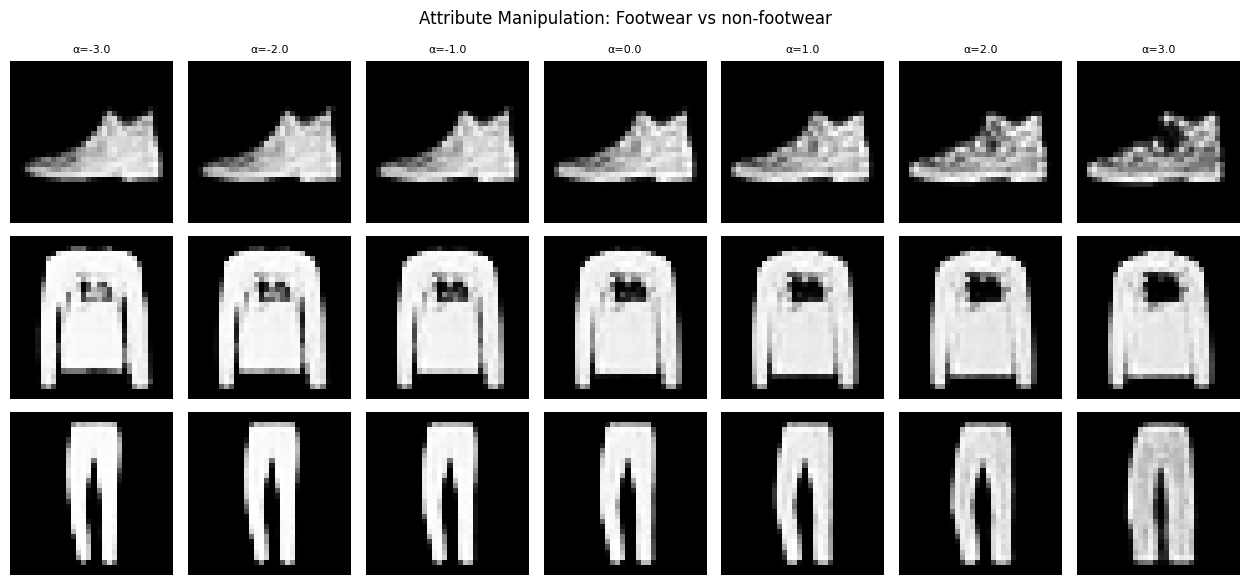

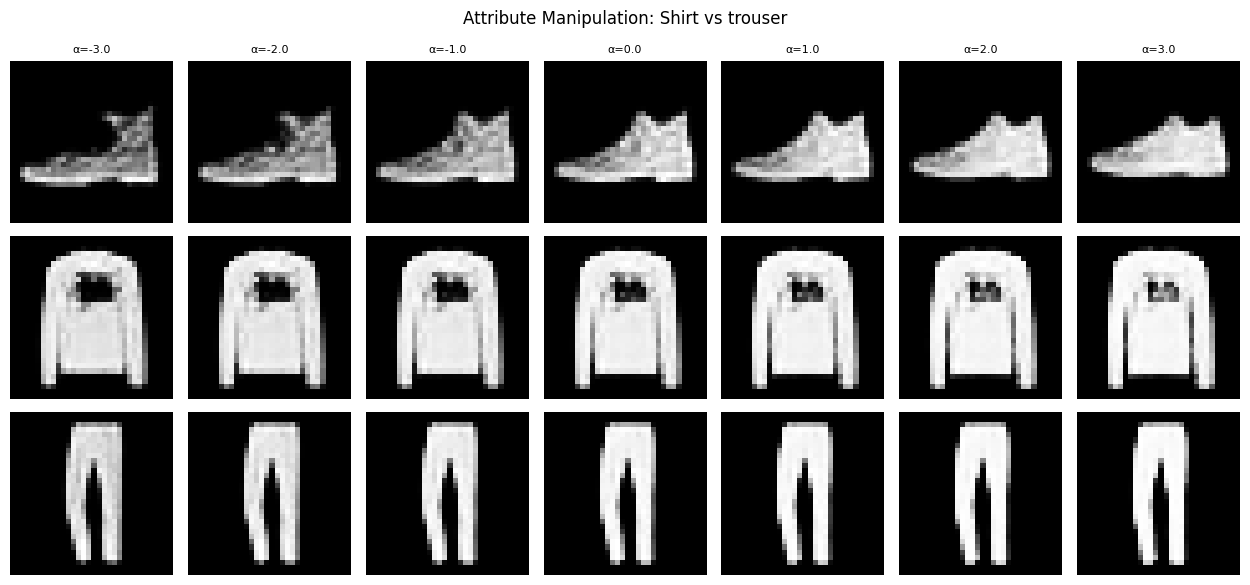

In [ ]:
# Evaluation 2: Attribute Manipulation

def get_attribute_direction(attr_name, label_filter_fn, train_ysem, train_lab):
    """ label_filter_fn(label) -> True/False for the positive class """
    y_binary = np.array([1 if label_filter_fn(l) else 0 for l in train_lab])
    scaler   = StandardScaler()
    X_sc     = scaler.fit_transform(train_ysem)

    svm = LinearSVC(max_iter=2000, C=1.0)
    svm.fit(X_sc, y_binary)
    acc = svm.score(X_sc, y_binary) * 100
    print(f"{attr_name:<25} SVM train acc: {acc:.1f}%")

    w = svm.coef_[0]
    return w / np.linalg.norm(w), scaler


print("Finding attribute directions...\n")
dir_footwear, scaler_footwear = get_attribute_direction(
    "Footwear vs non-footwear", lambda l: l in FOOTWEAR_LABELS, train_ysem, train_lab)
dir_shirt_trouser, scaler_st = get_attribute_direction(
    "Shirt vs trouser", lambda l: l == 6, train_ysem, train_lab)


def manipulate_attribute(attr_name, direction, scaler, n_test_images=3, n_steps=7):
    test_imgs, test_labels_batch = next(iter(test_loader))
    test_imgs = test_imgs[:n_test_images].to(device)

    with torch.no_grad():
        mu, logvar = vae.encode(test_imgs)
        z0 = vae.reparameterise(mu, logvar)
        y_sem_orig = sem_encoder(z0)

    timesteps_50 = get_respaced_timesteps(50, T)
    alphas_range = np.linspace(-3, 3, n_steps)

    fig, axes = plt.subplots(n_test_images, n_steps, figsize=(n_steps * 1.8, n_test_images * 2))

    for row in range(n_test_images):
        z_single = z0[row:row+1]
        y_single = y_sem_orig[row:row+1]

        # Invert to z_T ONCE per image, conditioned on its own original y_sem
        z_T = ddim_invert_conditional(ema_model, grad_estimator, z_single, y_single,
                                      alpha_bar, timesteps_50)

        for col, a in enumerate(alphas_range):
            y_sc = scaler.transform(y_single.cpu().numpy())
            y_moved = y_sc + a * direction
            y_moved = scaler.inverse_transform(y_moved)
            y_moved_t = torch.tensor(y_moved, dtype=torch.float32).to(device)

            z0_decoded = ddim_sample_conditional(ema_model, grad_estimator, z_T, y_moved_t,
                                                 alpha_bar, timesteps_50)
            with torch.no_grad():
                img_out = vae.decode(z0_decoded)

            axes[row, col].imshow(img_out[0, 0].cpu().numpy(), cmap='gray')
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(f'α={a:.1f}', fontsize=8)

    plt.suptitle(f'Attribute Manipulation: {attr_name}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'manip_{attr_name.replace(" ", "_")}_8_3.png', dpi=150)
    plt.show()


manipulate_attribute("Footwear vs non-footwear", dir_footwear, scaler_footwear)
manipulate_attribute("Shirt vs trouser", dir_shirt_trouser, scaler_st)

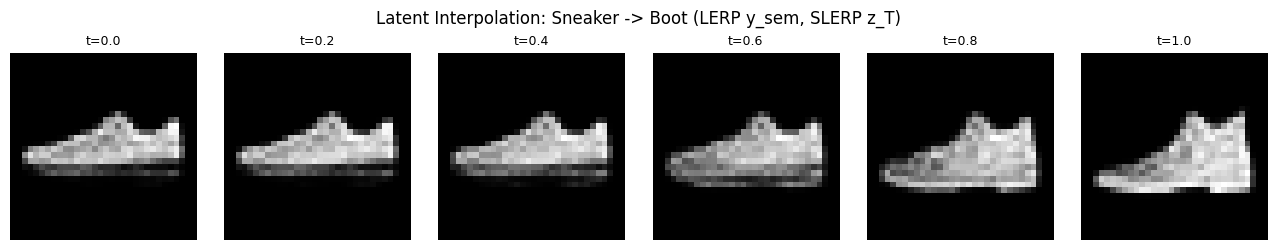

In [ ]:
# Evaluation 3: Latent Interpolation (Sneaker → Boot)

def lerp(a, b, t):
    return (1 - t) * a + t * b

def slerp(a, b, t, eps=1e-8):
    a_flat = a.flatten(); b_flat = b.flatten()
    a_norm = a_flat / (a_flat.norm() + eps)
    b_norm = b_flat / (b_flat.norm() + eps)
    dot       = torch.clamp((a_norm * b_norm).sum(), -1 + eps, 1 - eps)
    omega     = torch.acos(dot)
    sin_omega = torch.sin(omega) + eps
    coef1 = torch.sin((1 - t) * omega) / sin_omega
    coef2 = torch.sin(t * omega) / sin_omega
    return (coef1 * a_flat + coef2 * b_flat).view_as(a)


# Find one sneaker (label 7) and one boot (label 9)
test_full = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
sneaker_idx = (test_full.targets == 7).nonzero(as_tuple=True)[0][0].item()
boot_idx    = (test_full.targets == 9).nonzero(as_tuple=True)[0][0].item()

x_sneaker = test_full[sneaker_idx][0].unsqueeze(0).to(device)
x_boot    = test_full[boot_idx][0].unsqueeze(0).to(device)

with torch.no_grad():
    mu_s, lv_s = vae.encode(x_sneaker); z0_s = vae.reparameterise(mu_s, lv_s)
    mu_b, lv_b = vae.encode(x_boot);    z0_b = vae.reparameterise(mu_b, lv_b)
    y_sem_s = sem_encoder(z0_s)
    y_sem_b = sem_encoder(z0_b)

timesteps_50 = get_respaced_timesteps(50, T)
z_T_s = ddim_invert_conditional(ema_model, grad_estimator, z0_s, y_sem_s, alpha_bar, timesteps_50)
z_T_b = ddim_invert_conditional(ema_model, grad_estimator, z0_b, y_sem_b, alpha_bar, timesteps_50)

fractions = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
decoded_strip = []

for frac in fractions:
    t_tensor   = torch.tensor(frac, device=device)
    y_interp   = lerp(y_sem_s, y_sem_b, frac)          # LERP on y_sem
    z_T_interp = slerp(z_T_s, z_T_b, t_tensor)          # SLERP on z_T

    z0_decoded = ddim_sample_conditional(ema_model, grad_estimator, z_T_interp, y_interp,
                                         alpha_bar, timesteps_50)
    with torch.no_grad():
        img = vae.decode(z0_decoded)
    decoded_strip.append(img[0, 0].cpu().numpy())

fig, axes = plt.subplots(1, 6, figsize=(13, 2.5))
for i, (img, frac) in enumerate(zip(decoded_strip, fractions)):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f't={frac}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Latent Interpolation: Sneaker -> Boot (LERP y_sem, SLERP z_T)', fontsize=12)
plt.tight_layout()
plt.savefig('interp_sneaker_boot_8_3.png', dpi=150)
plt.show()

# Interpretation And Observation for Stage 3

#### The semantic encoder's linear probe accuracy of 47.10% on the full 10-way FashionMNIST classification task, well below both the VAE latent's 85.60% and even raw pixels' 82.20%, indicates that y_{sem} captured only a narrow, coarse signal rather than the rich, fine-grained representation the PDAE-style training objective is designed to extract. This is consistent with, and explained by, the other two results from this stage: the binary SVM probes for footwear-versus-non-footwear (90.1%) and shirt-versus-trouser (89.8%) succeeded because these are coarse, broadly silhouette-level distinctions that a weakly-trained encoder could still stumble onto, while distinguishing all ten specific categories from each other requires finer structural detail that was never extracted. The attribute manipulation strips showed no visible change across the full α range for any of the three test garments in either attribute, and the sneaker-to-boot interpolation strip's visible transition is better explained by the SLERP path on z_T — which moves between two real, independently-inverted noise codes already known from Exercise 5.2 to dominate decoded output — than by the LERP path on y_{sem}, which the manipulation result suggests was contributing little to the generation process. All three findings trace back to a single root cause: the gradient estimator, given only 50 epochs to learn a correction on top of an already-competent frozen LDM, did not learn a correction large enough to meaningfully steer generation, which in turn gave the semantic encoder a weak training signal and little pressure to extract anything beyond the crude features sufficient for the easy binary splits. This is not evidence that the PDAE strategy itself is unsound — LDAE's own published results, using the same underlying mechanism at full scale and training budget, achieve linear probe accuracy of 0.84 on real Alzheimer's MRI classification — but rather that this specific scaled-down implementation did not allocate enough training budget for the gradient estimator to do the job the method requires of it.

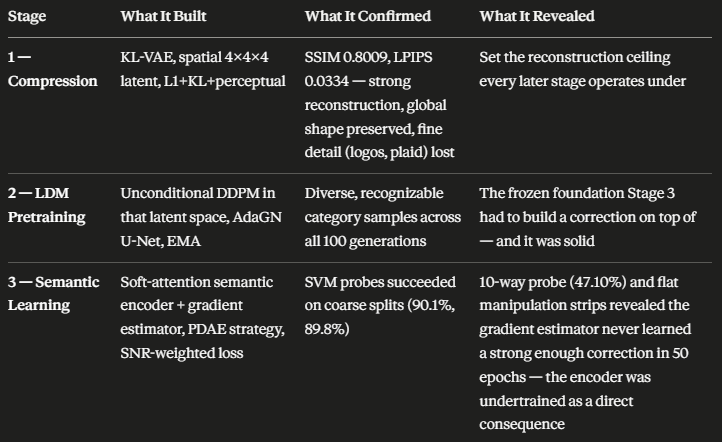


The throughline across all three stages is the same one that's surfaced repeatedly throughout this whole project, going back to the very first comparison between your CPU baseline (0.50 accuracy) and the real LDAE paper's target (0.84) in Module 1's introduction: the architecture and training mechanism are sound, but small-scale, short-budget runs on Colab reliably fall short of what the method is actually capable of at full scale. Stage 1 and Stage 2 had enough training budget relative to their task difficulty to succeed cleanly. Stage 3's task — training a representation purely from how well it helps correct a frozen model's predictions — is a substantially harder, more indirect learning signal, and 50 epochs simply wasn't enough budget for that harder problem, in exactly the way 30 epochs on a 64-channel network wasn't enough for the real GPU reproduction to hit paper-level numbers either. The mini end-to-end project succeeded at what it was actually designed to do: it gave us a complete, working, hands-on version of every mechanism in the real LDAE pipeline, and it surfaced — empirically, in our own results, not just in theory — exactly where and why representation quality in this family of models is fragile to training budget, which is the same lesson the real GPU reproduction confirmed at full scale matching all paper specs.